In [70]:
import collections
import os
import math
import random
import torch
import torchvision
from d2l import torch as d2l
import shutil
import pandas as pd
from torch import nn

In [71]:
print(pd.__version__)

2.0.3


In [72]:
text="      Hello World            "
print(text.strip())
print(text.lstrip())
print(text.rstrip())
a=[1,2,3]
b=[4,5,6]
print(dict(zip(a,b)))
print(dict([("a", 1), ("b", 2)]))

Hello World
Hello World            
      Hello World
{1: 4, 2: 5, 3: 6}
{'a': 1, 'b': 2}


In [73]:

d2l.DATA_HUB['cifar10_tiny'] = (d2l.DATA_URL + 'kaggle_cifar10_tiny.zip',
                                '2068874e4b9a9f0fb07ebe0ad2b29754449ccacd')

# 如果使用完整的Kaggle竞赛的数据集，设置demo为False
demo = True

if demo:
    data_dir = d2l.download_extract('cifar10_tiny')
else:
    data_dir = '../data/cifar-10/'
print(data_dir)

../data/kaggle_cifar10_tiny


In [74]:
def read_cvs_labels(filename):
    with open(filename, 'r') as f:
        lines = f.readlines()[1:]
        tokens = [l.rstrip().split(',') for l in lines]
        return dict((name,label) for name,label in tokens)
labels=read_cvs_labels(os.path.join(data_dir, 'trainLabels.csv'))
print(len(labels))
print(len(set(labels.values())))

1000
10


In [75]:
from collections import Counter

test_labels = ['apple', 'banana', 'apple', 'orange', 'banana', 'apple']
counter = Counter(labels.values())
print(counter.most_common()[-1][1])

85


In [76]:
def movefile(filename, target_dir):
    # 会自动创建对个目录
    shutil.mkdirs(target_dir, exist_ok=True)
    shutil.move(filename, target_dir)
def copyfile(filename, target_dir):
    # """将文件复制到目标目录""
    os.makedirs(target_dir, exist_ok=True)
    shutil.copy(filename, target_dir)

def reorg_train_valid(data_dir, labels, valid_ratio):
     # 训练数据集中样本最少的类别中的样本数
     n = collections.Counter(labels.values()).most_common()[-1][1]
     # 验证集中每个类别的样本数
     n_valid_per_label = max(1, math.floor(n * valid_ratio))
     label_count = {}
     for train_file in os.listdir(os.path.join(data_dir, 'train')):
         # 获取train目录下的每张图片的标签
         label = labels[train_file.split('.')[0]]
         fname=os.path.join(data_dir, 'train', train_file)
         copyfile(fname, os.path.join(data_dir, 'train_valid_test', 'train_valid', label))
         if label not in label_count or label_count[label] < n_valid_per_label:
             copyfile(fname, os.path.join(data_dir, 'train_valid_test', 'valid', label))
             # 统计每个类别的样本数，每次放入新的图片就加一
             label_count[label] = label_count.get(label, 0) + 1
         else:
             copyfile(fname, os.path.join(data_dir, 'train_valid_test',
                                         'train', label))
     return n_valid_per_label
 

In [77]:
def reorg_test(data_dir):
    """在预测期间整理测试集，以方便读取"""
    for test_file in os.listdir(os.path.join(data_dir, 'test')):
        copyfile(os.path.join(data_dir, 'test', test_file),
                 os.path.join(data_dir, 'train_valid_test', 'test',
                              'unknown'))

In [78]:
def reorg_cifar10_data(data_dir, valid_ratio):
    labels=read_cvs_labels(os.path.join(data_dir, 'trainLabels.csv'))
    reorg_train_valid(data_dir,labels,valid_ratio)
    reorg_test(data_dir)

In [ ]:
batch_size=8 if demo else 32
valid_ratio=0.1
reorg_cifar10_data(data_dir, valid_ratio)

In [80]:
from torchvision.models import vit_b_16, ViT_B_16_Weights
vit_transform=torchvision.models.ViT_B_16_Weights.DEFAULT.transforms()
# get_net()
print(vit_transform)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [81]:
# 数据增强
# transform_train = torchvision.transforms.Compose([
#     # 在高度和宽度上将图像放大到40像素的正方形
#     torchvision.transforms.Resize(40),
#     # 随机裁剪出一个高度和宽度均为40像素的正方形图像，
#     # 生成一个面积为原始图像面积0.64～1倍的小正方形，
#     # 然后将其缩放为高度和宽度均为32像素的正方形
#     torchvision.transforms.RandomResizedCrop(32, scale=(0.64, 1.0),
#                                                    ratio=(1.0, 1.0)),
#     torchvision.transforms.RandomHorizontalFlip(),
#     torchvision.transforms.ToTensor(),
#     # 标准化图像的每个通道
#     torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465],
#                                      [0.2023, 0.1994, 0.2010])])
# transform_test = torchvision.transforms.Compose([
#     torchvision.transforms.ToTensor(),
#     torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465],
#                                      [0.2023, 0.1994, 0.2010])])

In [82]:
# 使用Vit_transform进行数据增强，因为使用了vit_transform的预训练模型
train_ds, train_valid_ds = [torchvision.datasets.ImageFolder(
    os.path.join(data_dir, 'train_valid_test', folder),
    transform=vit_transform) for folder in ['train', 'train_valid']]
# [torchvision.datasets.ImageFolder label按照文件夹名字排好
valid_ds, test_ds = [torchvision.datasets.ImageFolder(
    os.path.join(data_dir, 'train_valid_test', folder),
    transform=vit_transform) for folder in ['valid', 'test']]

典型的工作流程：

训练阶段：用 train 训练模型，用 valid 验证并调整超参数。

最终训练阶段：用 train_valid（合并后的数据）重新训练模型（此时不再需要验证集，因为超参数已经固定）。

测试阶段：用 test 评估最终模型性能。

In [83]:
train_iter, train_valid_iter = [torch.utils.data.DataLoader(
    dataset, batch_size, shuffle=True, drop_last=True)
    for dataset in (train_ds, train_valid_ds)]
# drop_last=True means the last incomplete batch will be dropped

valid_iter = torch.utils.data.DataLoader(valid_ds, batch_size, shuffle=False,
                                         drop_last=True)

test_iter = torch.utils.data.DataLoader(test_ds, batch_size, shuffle=False,
                                        drop_last=False)

In [84]:

def get_net():
    num_classes = 10
    # 加载预训练的 ViT
    weight=torchvision.models.ViT_B_16_Weights
    net=vit_b_16(weights=weight.DEFAULT)
    # fine-tuning：替换分类头
    num_ftrs=net.heads.head.in_features
    net.fc=nn.Linear(num_ftrs,num_classes)
    return net
loss=nn.CrossEntropyLoss(reduction='none')
#     默认情况：如果不指定 reduction 或设置为 'mean'，损失会对所有样本的损失值求平均；如果设置为 'sum'，则对所有样本的损失值求和。
# reduction='none'：不进行任何聚合操作，直接返回每个样本的损失值。假设输入是一个 batch 大小为 N 的数据，则输出是一个形状为 (N,) 的张量，每个元素对应一个样本的损失。
    

In [85]:
x=[1,2,3]
print(isinstance(x,dict))
print(isinstance(x,list))

False
True


In [86]:
def train_batch_ch13(net, X, y, loss, trainer, devices):
    """使用多个GPU训练一个小批次（定义在第13章）
    
    定义在 :numref:`sec_image_augmentation` 章节"""
    
    # 将输入数据X转移到第一个GPU设备
    # 判断X是否属于List  
    if isinstance(X, list):
        # 用于BERT微调等特殊情况（后续章节会介绍）
        X = [x.to(devices[0]) for x in X]
    else:
        X = X.to(devices[0])
    
    # 将标签y转移到第一个GPU设备
    y = y.to(devices[0])
    
    # 设置网络为训练模式
    net.train()
    
    # 清空优化器的梯度
    trainer.zero_grad()
    
    # 前向传播计算预测值
    pred = net(X)
    
    # 计算损失
    l = loss(pred, y)
    
    # 反向传播计算梯度（使用mean()而不是sum()，避免受批次大小影响）
    l.mean().backward()
    
    # 更新模型参数
    trainer.step()
    
    # 计算批次总损失（用于后续统计）
    train_loss_sum = l.sum()
    
    # 计算批次准确率
    train_acc_sum = d2l.accuracy(pred, y)
    
    return train_loss_sum, train_acc_sum

In [99]:
# 参数配置Config
best_params = {'weight_decay': 3.1595250466032746e-05,
               'learning_rate': 5e-5,# 0.0007394699205144519
               'dropout_rate': 0.10845782679503657}

devices, num_epochs, lr, wd = d2l.try_all_gpus(), 30, best_params['learning_rate'], best_params['weight_decay']
lr_period, lr_decay, net = 4, 0.9, get_net()

In [100]:
import math
import torch
from torch.optim.lr_scheduler import LambdaLR

def cosine_warmup_scheduler(optimizer, warmup_epochs=5, max_epochs=num_epochs, max_lr=best_params['learning_rate']):
    def lr_lambda(current_epoch):
        if current_epoch < warmup_epochs:
            # 线性 warmup
            return float(current_epoch + 1) / float(warmup_epochs)
        else:
            # 余弦退火
            progress = (current_epoch - warmup_epochs) / (max_epochs - warmup_epochs)
            return 0.5 * (1.0 + math.cos(math.pi * progress))
        
    for param_group in optimizer.param_groups:
        param_group['lr'] = max_lr
    
    return LambdaLR(optimizer, lr_lambda)


In [101]:
def train(net, train_iter, valid_iter, num_epochs, lr, wd, devices, lr_period,
          lr_decay):
    # 初始化优化器：使用随机梯度下降（SGD），设置学习率、动量（momentum）和权重衰减（weight_decay）
    # trainer = torch.optim.SGD(net.parameters(), lr=lr, momentum=0.9,
                            #   weight_decay=wd)
    trainer=torch.optim.Adam(net.parameters(),lr=lr,weight_decay=wd)
    # 学习率调度器：warmup学习率策略和余弦退火学习率策略
    scheduler = cosine_warmup_scheduler(trainer)
    
    # 获取训练集的batch数量，并初始化计时器
    num_batches, timer = len(train_iter), d2l.Timer()
    
    # 设置动画显示图例（训练损失、训练准确率，如果有验证集则加上验证准确率）
    legend = ['train loss', 'train acc']
    if valid_iter is not None:
        legend.append('valid acc')
    
    # 初始化动画绘制器（用于可视化训练过程）
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=legend)
    
    # 使用多GPU并行训练（DataParallel），主设备为devices[0]
    net = nn.DataParallel(net, device_ids=devices).to(devices[0])
    # 开始训练循环
    for epoch in range(num_epochs):
        net.train()  # 设置模型为训练模式
        metric = d2l.Accumulator(3)  # 初始化累加器（用于累计损失、准确率、样本数）
        
        # 遍历训练集的每个batch
        for i, (features, labels) in enumerate(train_iter):
            timer.start()  # 开始计时
            
            # 训练一个batch，返回损失和准确率
            l, acc = train_batch_ch13(net, features, labels,
                                          loss, trainer, devices)
            
            # 累加当前batch的损失、准确率、样本数
            metric.add(l, acc, labels.shape[0])
            timer.stop()  # 停止计时
            
            # 每训练完约1/5的batch或最后一个batch时，更新训练曲线
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (metric[0] / metric[2], metric[1] / metric[2],
                              None))
        
        # 如果有验证集，计算验证集准确率并更新曲线
        if valid_iter is not None:
            net.eval()  # 设置模型为评估模式
            valid_acc = d2l.evaluate_accuracy_gpu(net, valid_iter)
            animator.add(epoch + 1, (None, None, valid_acc))
        
        scheduler.step()  # 更新学习率（按lr_period和lr_decay调整）
    
    # 打印训练结果
    measures = (f'train loss {metric[0] / metric[2]:.3f}, '
                f'train acc {metric[1] / metric[2]:.3f}')
    if valid_iter is not None:
        measures += f', valid acc {valid_acc:.3f}'
    
    # 打印训练速度（样本数/秒）和使用的设备
    print(measures + f'\n{metric[2] * num_epochs / timer.sum():.1f}'
          f' examples/sec on {str(devices)}')

train loss 0.000, train acc 1.000, valid acc 0.963
56.6 examples/sec on [device(type='cuda', index=0)]


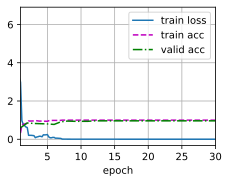

In [102]:
if demo:
    # 设置demo为True时进行小批量运行来获取最合适的超参数
    train(net, train_iter, valid_iter, num_epochs, lr, wd, devices, lr_period,
        lr_decay)
    # 0.547 valid acc
else:
    net, preds = get_net(), []
    net.eval()
    train(net, train_valid_iter, None, num_epochs, lr, wd, devices, lr_period,
        lr_decay)

    for X, _ in test_iter:
        y_hat = net(X.to(devices[0]))
        preds.extend(y_hat.argmax(dim=1).type(torch.int32).cpu().numpy())
    sorted_ids = list(range(1, len(test_ds) + 1))
    sorted_ids.sort(key=lambda x: str(x))
    df = pd.DataFrame({'id': sorted_ids, 'label': preds})
    df['label'] = df['label'].apply(lambda x: train_valid_ds.classes[x])
    df.to_csv('submission.csv', index=False)